# Quaks News Analyst

## Dependency Injection and Setup

In [1]:
%%capture
import os
import nest_asyncio
from IPython.display import HTML, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from app.core.container import Container
from app.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = Container()
container.init_resources()
container.wire(modules=[__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

### XAI Agent Workflow

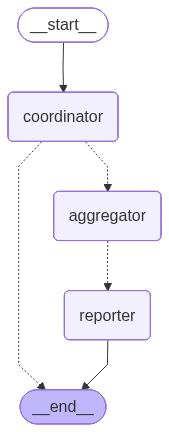

In [2]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="quaks_news_analyst", llm_tag="grok-4-1-fast-non-reasoning", api_key=os.getenv("XAI_API_KEY")
)
xai_news_analyst = container.quaks_news_analyst_agent()
xai_workflow_builder = xai_news_analyst.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)
experiment_utils.print_graph(xai_workflow)

---

### Invoke quaks-news-analyst

In [3]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Generate news insights.",
    agent_id=xai_agent["id"],
)

inputs = xai_news_analyst.get_input_params(message, schema="public")
config = xai_news_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_news_analyst.format_response(result)

In [4]:
display(HTML(ai_message_content))

---

### Ollama / gemma3:12b agent workflow

In [5]:
# Create Workflow
ollama_agent = experiment_utils.create_ollama_agent(
    agent_type="quaks_news_analyst", llm_tag="gemma3:12b", ollama_endpoint="http://moon:11434"
)
ollama_news_analyst = container.quaks_news_analyst_agent()
ollama_workflow_builder = ollama_news_analyst.get_workflow_builder(ollama_agent["id"])
ollama_workflow = ollama_workflow_builder.compile(checkpointer=checkpointer)

In [6]:
%%capture

inputs = ollama_news_analyst.get_input_params(message, schema="public")
config = ollama_news_analyst.get_config(ollama_agent["id"])
result = ollama_workflow.invoke(inputs, config)
ai_message_content, workflow_state = ollama_news_analyst.format_response(result)

In [7]:
display(HTML(ai_message_content))

---

## Ollama / gpt-oss agent workflow

In [8]:
# Create Workflow
ollama_agent = experiment_utils.create_ollama_agent(
    agent_type="quaks_news_analyst", llm_tag="gpt-oss", ollama_endpoint="http://moon:11434"
)
ollama_news_analyst = container.quaks_news_analyst_agent()
ollama_workflow_builder = ollama_news_analyst.get_workflow_builder(ollama_agent["id"])
ollama_workflow = ollama_workflow_builder.compile(checkpointer=checkpointer)

In [9]:
%%capture

inputs = ollama_news_analyst.get_input_params(message, schema="public")
config = ollama_news_analyst.get_config(ollama_agent["id"])
result = ollama_workflow.invoke(inputs, config)
ai_message_content, workflow_state = ollama_news_analyst.format_response(result)

In [10]:
display(HTML(ai_message_content))